<a href="https://colab.research.google.com/github/jennysaad/meliora/blob/eva/eva_jenny_pharmahacks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge 3: Detecting Alzheimer's disease and Frontotemporal dementia using Electroencephalograms

In 2025, it was estimated that 771,939 people in Canada are living with dementia, including Alzheimer's disease and Frontotemporal dementia. By 2030, this number is estimated to reach up to 1 million.

Early detection of these diseases is still not well developed, and current advancements in Deep Learning offer promising results.

For this challenge, you'll have the opportunity to work on a curated dataset Miltiadous et al. (2023) made of EEG recordings of healthy subjects and subjects diagnosed with Alzheimer's disease and Frontotemporal dementia.

## 1. What is an EEG ?

An electroencephalogram (EEG) is a test that measures brain electrical activity and can identify anomalies in brain waves linked to certain disorders . The test uses small, metal discs called electrodes that attach to the scalp. Brain cells communicate via electrical impulses, and this activity shows up as wavy lines on an EEG recording. Brain cells are active all the time, even during sleep.



## 2. Dataset description

This dataset contains the EEG resting state-closed eyes recordings from 88 subjects in
total. A total of 36 of them were diagnosed with Alzheimer’s disease (AD group), 23 were
diagnosed with frontotemporal dementia (FTD group), and 29 were CN.

Recordings include the EEG signal from 19 scalp electrodes (Fp1, Fp2, F7, F3, Fz,
F4, F8, T3, C3, Cz, C4, T4, T5, P3, Pz, P4, T6, O1, and O2) and 2 reference electrodes,
placed according to the 10–20 international system. The sampling rate was 500 Hz and the
resolution was 10 uV/mm. Each recording lasted approximately 13.5 min for the AD group
(min = 5.1, max = 21.3), 12 min for the FTD group (min = 7.9, max = 16.9), and 13.8 min for
the CN group (min = 12.5, max = 16.5). In total, 485.5 min of AD, 276.5 min of FTD, and
402 min of CN recordings were collected and are included in the dataset.

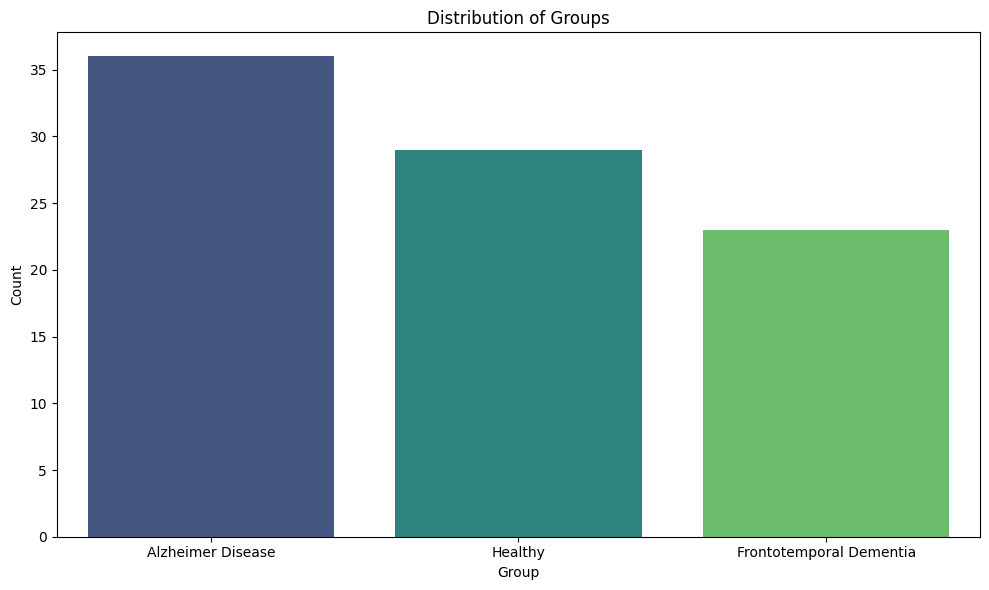



## 3.Problem

Using the EEG recordings, there are two binary classification tasks you can choose:
1. AD vs CN: classify whether a patient has Alzheimer’s disease or not
2. FTD vs CN: classify whether a patient has Frontotemporal dementia or not



## 4. Starting code

Below is a list of helper functions to help you work with the dataset, as well as some visualization starting code.

In [1]:
# Import these libraries to enable helper functions
!
import os # Added by Jenny + Eva
import numpy as np
import pywt
import pandas as pd
import torch
import matplotlib.pyplot as plt
from google.colab import drive
from scipy.signal import welch, resample

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
'''
Helper functions; you don't need to modify these.

'''

def load_npy(path):
  return np.load(path, allow_pickle=True)

def filter_subjects(df, drop_label):
    '''
    Returns the subjects array relevant to the task chosen.

    Args:
      df: the dataframe that maps each subject to its corresponding label (A, C, or F)
      drop_label: the label that is not relevant to the task chosen. Example: if i'm doing A vs C classification, then the drop label would be 'F'
    '''
    return df[df['label'] != drop_label]['anonymized_id']

def extract_features(eeg_data, sfreq, target_time_steps=30):
    """
    Extracts RBP (Welch) and SCC (PyWavelets CWT).

    Args:
        eeg_data: (Channels, Time) - A single 30-second epoch.
        sfreq: Sampling frequency (e.g., 128).
        target_time_steps: Number of time windows (30 for DICE-net).
    Returns:
        rbp: (30, 5, 19)
        scc: (30, 5, 19)
    """

    # You need to have the PyWavelet package installed to run this function
    # Uncomment the next lines to make sure you have it installed
    #!pip install PyWavelets
    #import pywt

    n_channels, n_points = eeg_data.shape
    segment_len = int(n_points / target_time_steps)

    # ---------------------------------------------------------
    # 1. Relative Band Power (RBP)
    # ---------------------------------------------------------
    bands = [(0.5, 4), (4, 8), (8, 13), (13, 25), (25, 45)]
    rbp_features = np.zeros((target_time_steps, 5, n_channels))

    for t in range(target_time_steps):
        start = t * segment_len
        end = start + segment_len
        segment = eeg_data[:, start:end]

        freqs, psd = welch(segment, fs=sfreq, nperseg=segment_len, axis=1)

        total_power = np.sum(psd, axis=1, keepdims=True)
        total_power[total_power == 0] = 1e-10

        for b_idx, (fmin, fmax) in enumerate(bands):
            idx = np.logical_and(freqs >= fmin, freqs <= fmax)
            band_power = np.sum(psd[:, idx], axis=1)
            rbp_features[t, b_idx, :] = band_power / total_power.flatten()

    # ---------------------------------------------------------
    # 2. Spectral Coherence Connectivity (SCC) - Using PyWavelets
    # ---------------------------------------------------------
    morlet_freqs = np.array([2, 6, 10, 18, 35])
    wavelet_name = 'cmor1.5-1.0'  # Complex Morlet (bandwidth 1.5, center freq 1.0)

    # Convert target frequencies (Hz) to Wavelet Scales
    # Scale = (Center_Freq * Sampling_Rate) / Target_Freq
    center_freq = pywt.central_frequency(wavelet_name)
    scales = (center_freq * sfreq) / morlet_freqs

    # Pre-allocate coefficients storage: (Channels, Bands, Time)
    coeffs_all = np.zeros((n_channels, len(morlet_freqs), n_points), dtype=np.complex128)

    # Compute CWT for each channel
    # pywt.cwt returns (coeffs, freqs) where coeffs is (len(scales), len(data))
    for ch in range(n_channels):
        cwt_out, _ = pywt.cwt(eeg_data[ch], scales, wavelet_name, sampling_period=1/sfreq)
        coeffs_all[ch, :, :] = cwt_out

    # Calculate Coherence for each 1-second window
    scc_features = np.zeros((target_time_steps, 5, n_channels))

    for t in range(target_time_steps):
        start = t * segment_len
        end = start + segment_len

        for b_idx in range(len(morlet_freqs)):
            # Get coefficients for this specific band and time window
            # Shape: (n_channels, n_samples_in_window)
            seg_coeffs = coeffs_all[:, b_idx, start:end]

            # --- Vectorized Coherence Calculation ---

            # 1. Cross-Spectral Density Matrix (CSD): X * Y_conjugate
            # Result is (19, 19) matrix of summed cross-products
            csd_matrix = seg_coeffs @ seg_coeffs.conj().T

            # 2. Power Spectral Density (Diagonal of CSD)
            psd_vec = np.diag(csd_matrix).real

            # 3. Denominator: sqrt(PSD_x * PSD_y)
            denom = np.sqrt(np.outer(psd_vec, psd_vec))
            denom[denom == 0] = 1e-10 # Safe division

            # 4. Coherence: |CSD| / Denominator
            coherence_matrix = np.abs(csd_matrix) / denom

            # 5. Average Coherence (SCC) per channel
            # "SCC involves calculating spectral coherence... and averaging these values for each electrode."
            scc_val = np.mean(coherence_matrix, axis=1)

            scc_features[t, b_idx, :] = scc_val

    return rbp_features, scc_features

def reduce_eeg_size(eeg_data, target_length):
    """
    Reduces the size of EEG data to a uniform length for all patients.

    Parameters:
        eeg_data (list of np.array): List of EEG recordings, where each recording is a 2D array
                                     (channels x time points).
        target_length (int): The desired number of time points for each patient's data.

    Returns:
        np.array: A 3D array of shape (patients, channels, target_length).
    """
    reduced_data = []

    patient_data : np.ndarray
    for patient_data in eeg_data:
        # Resample each channel of the patient's data to the target length
        num_channels, orig_length = patient_data.shape
        if orig_length > target_length:
            resampled_patient_data = np.zeros((num_channels, target_length))

            for i in range(num_channels):
                resampled_patient_data[i] = resample(patient_data[i], target_length)

            reduced_data.append(resampled_patient_data)
        else:
            reduced_data.append(patient_data)
    return np.array(reduced_data)

def pad_eeg_data(eeg_data, target_length):
    """
    Pads EEG data to a uniform length for all patients.
    Parameters:
        eeg_data (list of np.array): List of EEG recordings, where each

        recording is a 2D array (channels x time points).
        target_length (int): The desired number of time points for each patient's data.
        Returns:
        np.array: A 3D array of shape (patients, channels, target_length).
    """
    padded_data = []
    for patient_data in eeg_data:
        num_channels, orig_length = patient_data.shape
        if orig_length < target_length:
            padding = np.zeros((num_channels, target_length - orig_length))
            padded_data.append(np.hstack((patient_data, padding)))

        else:
            padded_data.append(patient_data)
    return np.array(padded_data)

def generate_dataset(data_list, labels, subject_ids, sfreq=128):
    """
    Args:
        data_list: List of numpy arrays, each shape (channels, time)
        labels: List or array of group labels
        subject_ids: List or array of subject identifiers. In your case, this should just be the first column of the label mapping CSV file.
        sfreq: Sampling frequency
    """
    X_rbp_list = []
    X_scc_list = []
    y_list = []
    groups_list = []

    window_samples = 30 * sfreq
    step_samples = 15 * sfreq

    for data, label, s_id in zip(data_list, labels, subject_ids):

        n_points = data.shape[1]

        # Sliding Window
        for start in range(0, n_points - window_samples + 1, step_samples):
            epoch = data[:, start : start + window_samples]

            rbp, scc = extract_features(epoch, sfreq)

            X_rbp_list.append(rbp)
            X_scc_list.append(scc)
            y_list.append(label)
            groups_list.append(s_id)

    X_rbp = torch.tensor(np.array(X_rbp_list), dtype=torch.float32)
    X_scc = torch.tensor(np.array(X_scc_list), dtype=torch.float32)
    y = torch.tensor(np.array(y_list), dtype=torch.float32).unsqueeze(1)
    groups = np.array(groups_list)

    return X_rbp, X_scc, y, groups

In [ ]:
# Example starter code
path = '/content/drive/MyDrive/example.npy' # Replace with your path
data = load_npy(path)

n_channels, time_points = data.shape
print(f'Number of channels: {n_channels}, Number of time_points: {time_points}')

Number of channels: 19, Number of time_points: 119608


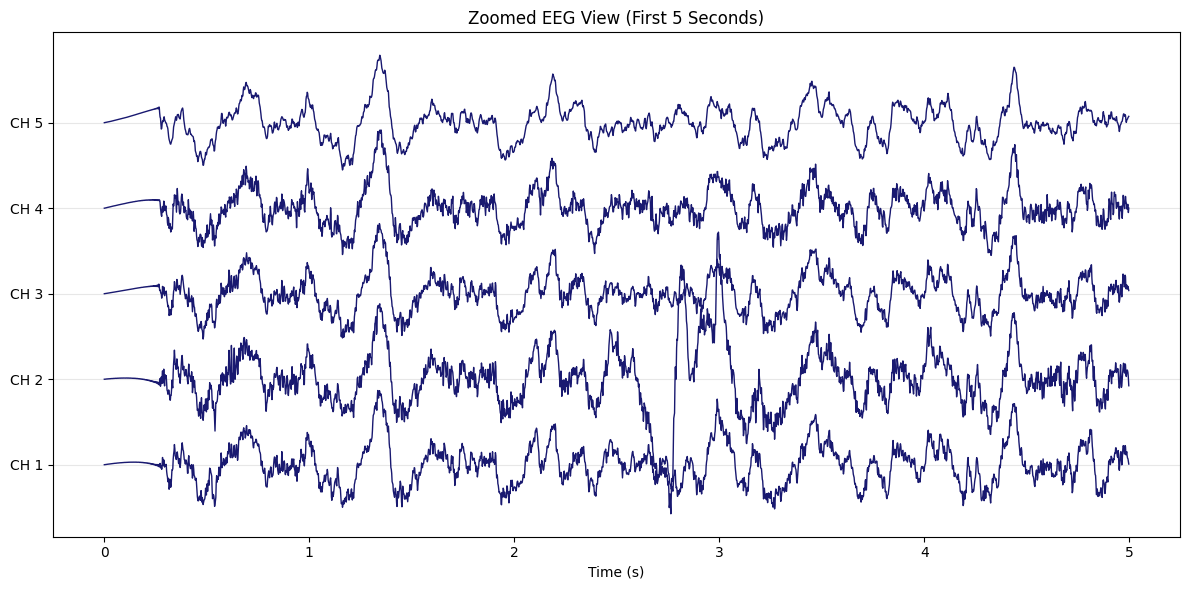

In [ ]:
# Visualize the sample data
fs = 500
duration = 5
max_samples = int(fs * duration)


subset_data = data[:5, :max_samples]
time = np.arange(max_samples) / fs

spacing = 100
scaling_factor = spacing / (np.std(subset_data) * 4)
scaled_data = subset_data * scaling_factor

# 3. Plotting
plt.figure(figsize=(12, 6))
offsets = np.arange(len(subset_data)) * spacing

for i in range(len(subset_data)):
    plt.plot(time, scaled_data[i] + offsets[i], linewidth=1, color='midnightblue')

# 4. Cleanup
plt.yticks(offsets, [f'CH {i+1}' for i in range(len(subset_data))])
plt.xlabel('Time (s)')
plt.title('Zoomed EEG View (First 5 Seconds)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

In [4]:
# cell 3 jenny + eva
# Load the CSV label file

# read csv file into a pandas dataframe
labels_df = pd.read_csv('/content/drive/MyDrive/training/train_label_mapping.csv')

# check it loaded correctly
# returns number of rows
print(f"Total subjects in the CSV: {len(labels_df)}")
print()

# peeking at the first 10 rows - sanity check
print("First 10 rows (preview):")
print(labels_df.head(10))
print()

# number of time label appears
# returns how many entries of each there is
print("How many subjects in each group:")
print(labels_df['label'].value_counts())

Total subjects in the CSV: 54

First 10 rows (preview):
   anonymized_id label
0              2     F
1              3     A
2              4     A
3              8     A
4              9     A
5             10     C
6             13     F
7             14     F
8             15     F
9             16     F

How many subjects in each group:
label
A    25
F    16
C    13
Name: count, dtype: int64


In [5]:
# cell 4 jenny + eva
# Filter for AD vs CN

# --- step 1: get list of relevant subject IDs ---
# identify the IDs of the non-F people
subject_ids_for_task = filter_subjects(labels_df, drop_label='F')

# how many subjects are non-F (in the identified list)
print(f"Subjects for AD vs CN: {len(subject_ids_for_task)}")

# print the ID of the non-F people in an increasing orderd
print(f"Their IDs: {sorted(subject_ids_for_task.values)}")

# --- Step 2: create df with binary labels ---
# this is a copy of table labels_df without the rows containing label F
# task_df is a table
task_df = labels_df[labels_df['anonymized_id'].isin(subject_ids_for_task.values)].copy()

# create a new column binary_label with 0 and 1 instead of C and A
# it's technically a deep copy
task_df['binary_label'] = task_df['label'].map({'A': 1, 'C': 0})

# how many of our rows have 1 in the binary_label column
# aka how many people in the table have alzeimer
ad_count = (task_df['binary_label'] == 1).sum()

# same thing for healthy people
cn_count = (task_df['binary_label'] == 0).sum()

print(f"\nAlzheimer's subjects (label=1): {ad_count}")
print(f"Healthy subjects (label=0): {cn_count}")

Subjects for AD vs CN: 38
Their IDs: [np.int64(3), np.int64(4), np.int64(8), np.int64(9), np.int64(10), np.int64(18), np.int64(23), np.int64(24), np.int64(27), np.int64(28), np.int64(30), np.int64(32), np.int64(34), np.int64(39), np.int64(40), np.int64(42), np.int64(44), np.int64(46), np.int64(48), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(55), np.int64(56), np.int64(61), np.int64(64), np.int64(69), np.int64(70), np.int64(73), np.int64(75), np.int64(76), np.int64(78), np.int64(81), np.int64(82), np.int64(84), np.int64(85), np.int64(86)]

Alzheimer's subjects (label=1): 25
Healthy subjects (label=0): 13


In [ ]:
# cell 5 jenny + eva
# Load all EEG files

# string obtainign path to training data
base = '/content/drive/MyDrive/training'

# Create three empty lists. We'll fill them as we load each subject.
data_list = [] # Will hold numpy arrays (brain recordings)
labels_list = [] # Will hold integers (0 = healthy, 1 = AD)
ids_list = [] # Will hold integers (subject ID numbers)

# loop through the 2 relevant folders

# iterate through AD and CN folders
for group_folder, label_value in [('AD', 1), ('CN', 0)]:
  # build a path to folder
  folder_path =f'{base}/{group_folder}'

  # check if folder actually exists on google drive
  if not os.path.exists(folder_path):
      print(f"WARNING: Folder not found: {folder_path}")
      continue  # skip to next folder

  # print which folder we're about to load from
  group_name = "Alzheimer's (AD)" if label_value == 1 else "Healthy (CN)"
  print(f"Loading from {group_name} folder: {folder_path}")

  # get list of every file in the folder and go through them one by one
  for fname in sorted(os.listdir(folder_path)):

      # ignore any file that isn't a .npy file (like hidden files)
      if not fname.endswith('.npy'):
          continue

      # extract the subject ID number from the filename
      # "3.npy" → remove ".npy" → "3" → convert text to number → 3
      subject_id = int(fname.replace('.npy', ''))

      # skip this subject if they're not in our filtered AD vs CN list
      # some files in the folder might not be in the CSV
      if subject_id not in subject_ids_for_task.values:
          continue

      # build full path to the file and load it
      filepath = f'{folder_path}/{fname}'
      # np.load reads the .npy file and gives us a numpy array (grid of numbers)
      data = np.load(filepath, allow_pickle=True)

      # add this subject's info to our three lists
      # all three lists grow together — they stay in sync
      data_list.append(data)       # the brain recording
      labels_list.append(label_value)  # 0 or 1
      ids_list.append(subject_id)      # their ID number

      # print what we loaded so we can see it working
      # convert time points to minutes so it's human readable
      duration_min = data.shape[1] / 500 / 60
      label_text = "AD" if label_value == 1 else "CN"
      print(f"  {label_text} | Subject {subject_id:3d} | shape {data.shape} | {duration_min:.1f} min")

# print how many we loaded total
print(f"\nFinished loading {len(data_list)} subjects total.")
print(f"  AD subjects: {sum(1 for l in labels_list if l == 1)}")
print(f"  CN subjects: {sum(1 for l in labels_list if l == 0)}")

# crash on purpose if the three lists aren't the same length
# better to catch a bug now than get garbage results later
assert len(data_list) == len(labels_list) == len(ids_list), \
    "BUG: The three lists have different lengths!"
print("All three lists are the same length")

In [ ]:
# cell 6 jenny + eva
# two charts for the presentation

# --- CHART 1: what raw brain waves look like ---

# names of the 19 electrodes in order (matching the rows of our arrays)
channel_names = ['Fp1','Fp2','F7','F3','Fz','F4','F8','T3','C3',
                 'Cz','C4','T4','T5','P3','Pz','P4','T6','O1','O2']

# grab the first subject's recording to plot
example = data_list[0]
fs = 500          # 500 samples per second (from the challenge PDF)
duration = 5      # only plot 5 seconds (plotting all 10+ min would be chaos)
n_ch = 5          # only plot 5 channels (all 19 would overlap too much)
max_samples = int(fs * duration)  # 500 × 5 = 2500 data points to plot

# slice out first 5 channels and first 2500 time points
subset = example[:n_ch, :max_samples]

# create the time axis in seconds
# np.arange(2500) = [0, 1, 2, ... 2499], divide by 500 to get seconds
time = np.arange(max_samples) / fs

# scale the data so the 5 channels don't draw on top of each other
spacing = 100
scaling_factor = spacing / (np.std(subset) * 4)
scaled = subset * scaling_factor

# actually draw the plot
plt.figure(figsize=(12, 6))
offsets = np.arange(n_ch) * spacing
for i in range(n_ch):
    plt.plot(time, scaled[i] + offsets[i], linewidth=0.8)
plt.yticks(offsets, channel_names[:n_ch])
plt.xlabel('Time (seconds)')
plt.title(f'Raw EEG — Subject {ids_list[0]} (First 5 Seconds)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- CHART 2: how many AD vs healthy people we have ---

ad_count = sum(1 for l in labels_list if l == 1)
cn_count = sum(1 for l in labels_list if l == 0)

plt.figure(figsize=(6, 4))
plt.bar(["Healthy (CN)", "Alzheimer's (AD)"], [cn_count, ad_count],
        color=['steelblue', 'coral'])
plt.ylabel('Number of Subjects')
plt.title('Training Set: Class Distribution')
# stick the actual number on top of each bar
for i, v in enumerate([cn_count, ad_count]):
    plt.text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# ratio tells us the dataset is imbalanced (more AD than healthy)
# When working the model we will deal with this using class_weight='balanced' - See notes on pinned discord channel Jenny + Eva
print(f"AD/CN ratio: {ad_count}/{cn_count} = {ad_count/cn_count:.2f}")

In [ ]:
# cell 7 jenny + eva
# what the function does internally:
# 1. shrinks data from 500Hz to 128Hz (less data, keeps all useful info)
# 2. cuts each recording into 30-second chunks with 15-second overlap
# 3. for each chunk, calculates band power (RBP) — how strong each brain wave type is
# 4. for each chunk, calculates coherence (SCC) — how synchronized brain regions are
# 5. packages everything into pytorch tensors

print("=" * 60)
print("STARTING FEATURE EXTRACTION")
print("=" * 60)
print(f"Processing {len(data_list)} subjects...")
print("This takes 15-30 minutes. Don't close the tab.")
print()

# generate_data set from starter code
X_rbp, X_scc, y_tensor, groups = generate_dataset(
    data_list,    # our list of brain recordings from cell 5
    labels_list,  # our list of 0s and 1s from cell 5
    ids_list,     # our list of subject IDs from cell 5
    sfreq=128     # downsample to 128 samples per second
)

# see what we got back
print()
print("=" * 60)
print("FEATURE EXTRACTION COMPLETE")
print("=" * 60)
print(f"  X_rbp (band powers):  {X_rbp.shape}")
print(f"  X_scc (coherence):    {X_scc.shape}")
print(f"  y (labels):           {y_tensor.shape}")
print(f"  groups (subject IDs): {groups.shape}")
print(f"  Unique subjects:      {len(np.unique(groups))}")

In [ ]:
# cell 8 jenny + eva
# flatten the 4D cube into a flat spreadsheet that sklearn can use

# right now the shape is (num_windows, 30, 5, 19) — a 4D cube
# sklearn models need (num_windows, 190) — a flat table, one row per window

# so we squish it down step by step

# step 1: convert from pytorch tensors to numpy arrays
# same numbers, just a different container that sklearn can read
rbp_np = X_rbp.numpy()
scc_np = X_scc.numpy()
print(f"Step 1 — Converted to numpy: {rbp_np.shape}")

# step 2: average across the 30 one-second slices
# we don't need second-by-second detail, just the overall average per window
# (num_windows, 30, 5, 19) → (num_windows, 5, 19)
# aka collapse 30 measurements into 1 average
rbp_avg = np.mean(rbp_np, axis=1)
scc_avg = np.mean(scc_np, axis=1)
print(f"Step 2 — Averaged over time: {rbp_avg.shape}")

# step 3: flatten the 5×19 grid into one long row of 95 numbers
# like reading a small spreadsheet left-to-right, top-to-bottom
# (num_windows, 5, 19) → (num_windows, 95)
# the -1 means "figure out this number yourself" (5×19=95)
rbp_flat = rbp_avg.reshape(len(rbp_avg), -1)
scc_flat = scc_avg.reshape(len(scc_avg), -1)
print(f"Step 3 — Flattened: {rbp_flat.shape}")

# step 4: glue band power (95 columns) and coherence (95 columns) side by side
# (num_windows, 95) + (num_windows, 95) → (num_windows, 190)
X = np.hstack([rbp_flat, scc_flat])
print(f"Step 4 — Combined: {X.shape}")

# step 5: convert labels from pytorch format to plain 0s and 1s
# .squeeze() removes the pointless extra wrapper: (num_windows, 1) → (num_windows,)
# aka [[0],[1],[1]] becomes [0, 1, 1]
# .astype(int) turns 0.0 and 1.0 into plain 0 and 1
y = y_tensor.squeeze().numpy().astype(int)
print(f"Step 5 — Labels: {y.shape}, values: {np.unique(y)}")

# step 6: subject IDs — tracks which person each window came from
# already numpy from generate_dataset so nothing to convert
subject_ids = groups
print(f"Step 6 — Subject IDs: {subject_ids.shape}, {len(np.unique(subject_ids))} subjects")

# step 7: replace any broken values (NaN or Infinity) with 0
# these can happen if a channel had zero signal (dividing by zero)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
print(f"Step 7 — Cleaned NaN/Inf: {np.isnan(X).any()=}, {np.isinf(X).any()=}")

# done
print(f"\n{'='*60}")
print(f"{'='*60}")
print(f"  X: {X.shape} ({X.shape[0]} windows × {X.shape[1]} features)")
print(f"  y: {y.shape} ({(y==0).sum()} healthy, {(y==1).sum()} AD)")
print(f"  subject_ids: {subject_ids.shape} ({len(np.unique(subject_ids))} subjects)")
print()
print("X, y, and subject_ids are ready")